# ASL Sign Detection — YOLOv11 Training

Trains YOLOv11 on the Roboflow ASL alphanumeric signs dataset.

Written for use in Google Colab

**Before you start:**
1. Runtime → Change runtime type → **T4 GPU**
2. Replace Cell 3's [Insert-API-Key-Here] with an actual Roboflow API key. It is currently removed for security.

Expected total runtime on a T4: ~2 hours 30 mins for 20 epochs on ~15k training/validation images.

---

In [ ]:
# Install YOLOv11 framework and Roboflow client
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 35.1 MB/s eta 0:00:00


In [ ]:
# Verify CUDA is available before training
import torch
from ultralytics import YOLO

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device:          {torch.cuda.get_device_name(0)}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.10.0+cu128
CUDA available:  True
Device:          Tesla T4


In [ ]:
# Download dataset to Colab's local filesystem
from roboflow import Roboflow

rf = Roboflow(api_key="[Insert-API-Key-Here]")
project = rf.workspace("aphanachone").project("asl-alphanumeric-signs-2")
dataset = project.version(1).download("yolov11")

print(f'\nDataset downloaded to: {dataset.location}')

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ASL-Alphanumeric-Signs-2-1 in yolov11:: 100%|██████████| 38765/38765 [00:23<00:00, 1634.13it/s] 



Dataset downloaded to: /content/ASL-Alphanumeric-Signs-2-1


In [ ]:
# Display dataset config that YOLO will use for training
import os
yaml_path = os.path.join(dataset.location, 'data.yaml')
with open(yaml_path) as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 36
names: ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

roboflow:
  workspace: aphanachone
  project: asl-alphanumeric-signs-2
  version: 1
  license: MIT
  url: https://universe.roboflow.com/aphanachone/asl-alphanumeric-signs-2/dataset/1


## Training

- `epochs=20` — proven enough for this dataset based on prior runs
- `imgsz=640` — YOLO's standard training resolution
- `batch=32` — set for T4's 16 GB VRAM
- `patience=5` — stop early if validation mAP plateaus for 5 epochs // *Never used with 20 Epochs*
- `name='asl_yolov11'` — output folder name under `runs/detect/` to extract trained weights

In [ ]:
# Fine-tune YOLOv11n on ASL dataset
model = YOLO('yolo11n.pt')

results = model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=32,
    patience=5,
    name='asl_yolov11',
    plots=True,
    save=True,
    verbose=True,
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ASL-Alphanumeric-Signs-2-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=asl_yolov11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

In [ ]:
# Run validation on best weights
run_dir = 'runs/detect/asl_yolov11'
best_pt = os.path.join(run_dir, 'weights', 'best.pt')
model = YOLO(best_pt)
metrics = model.val(data=yaml_path, imgsz=640, plots=True, verbose=False)

print(f'\nValidation metrics:')
print(f'  mAP@0.5:       {metrics.box.map50:.3f}')
print(f'  mAP@0.5–0.95:  {metrics.box.map:.3f}')
print(f'  Precision:     {metrics.box.mp:.3f}')
print(f'  Recall:        {metrics.box.mr:.3f}')

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,589,172 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1080.9±1345.2 MB/s, size: 169.2 KB)
val: Scanning /content/ASL-Alphanumeric-Signs-2-1/valid/labels.cache... 1938 images, 49 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1938/1938 541.9Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2, len(boxes) = 1897. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 122/122 3.4it/s 35.5s
                   all       1938       1897      0.973      0.937      0.977      0.831
Speed: 1.2ms preprocess, 4.5ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /co


=== results.png ===


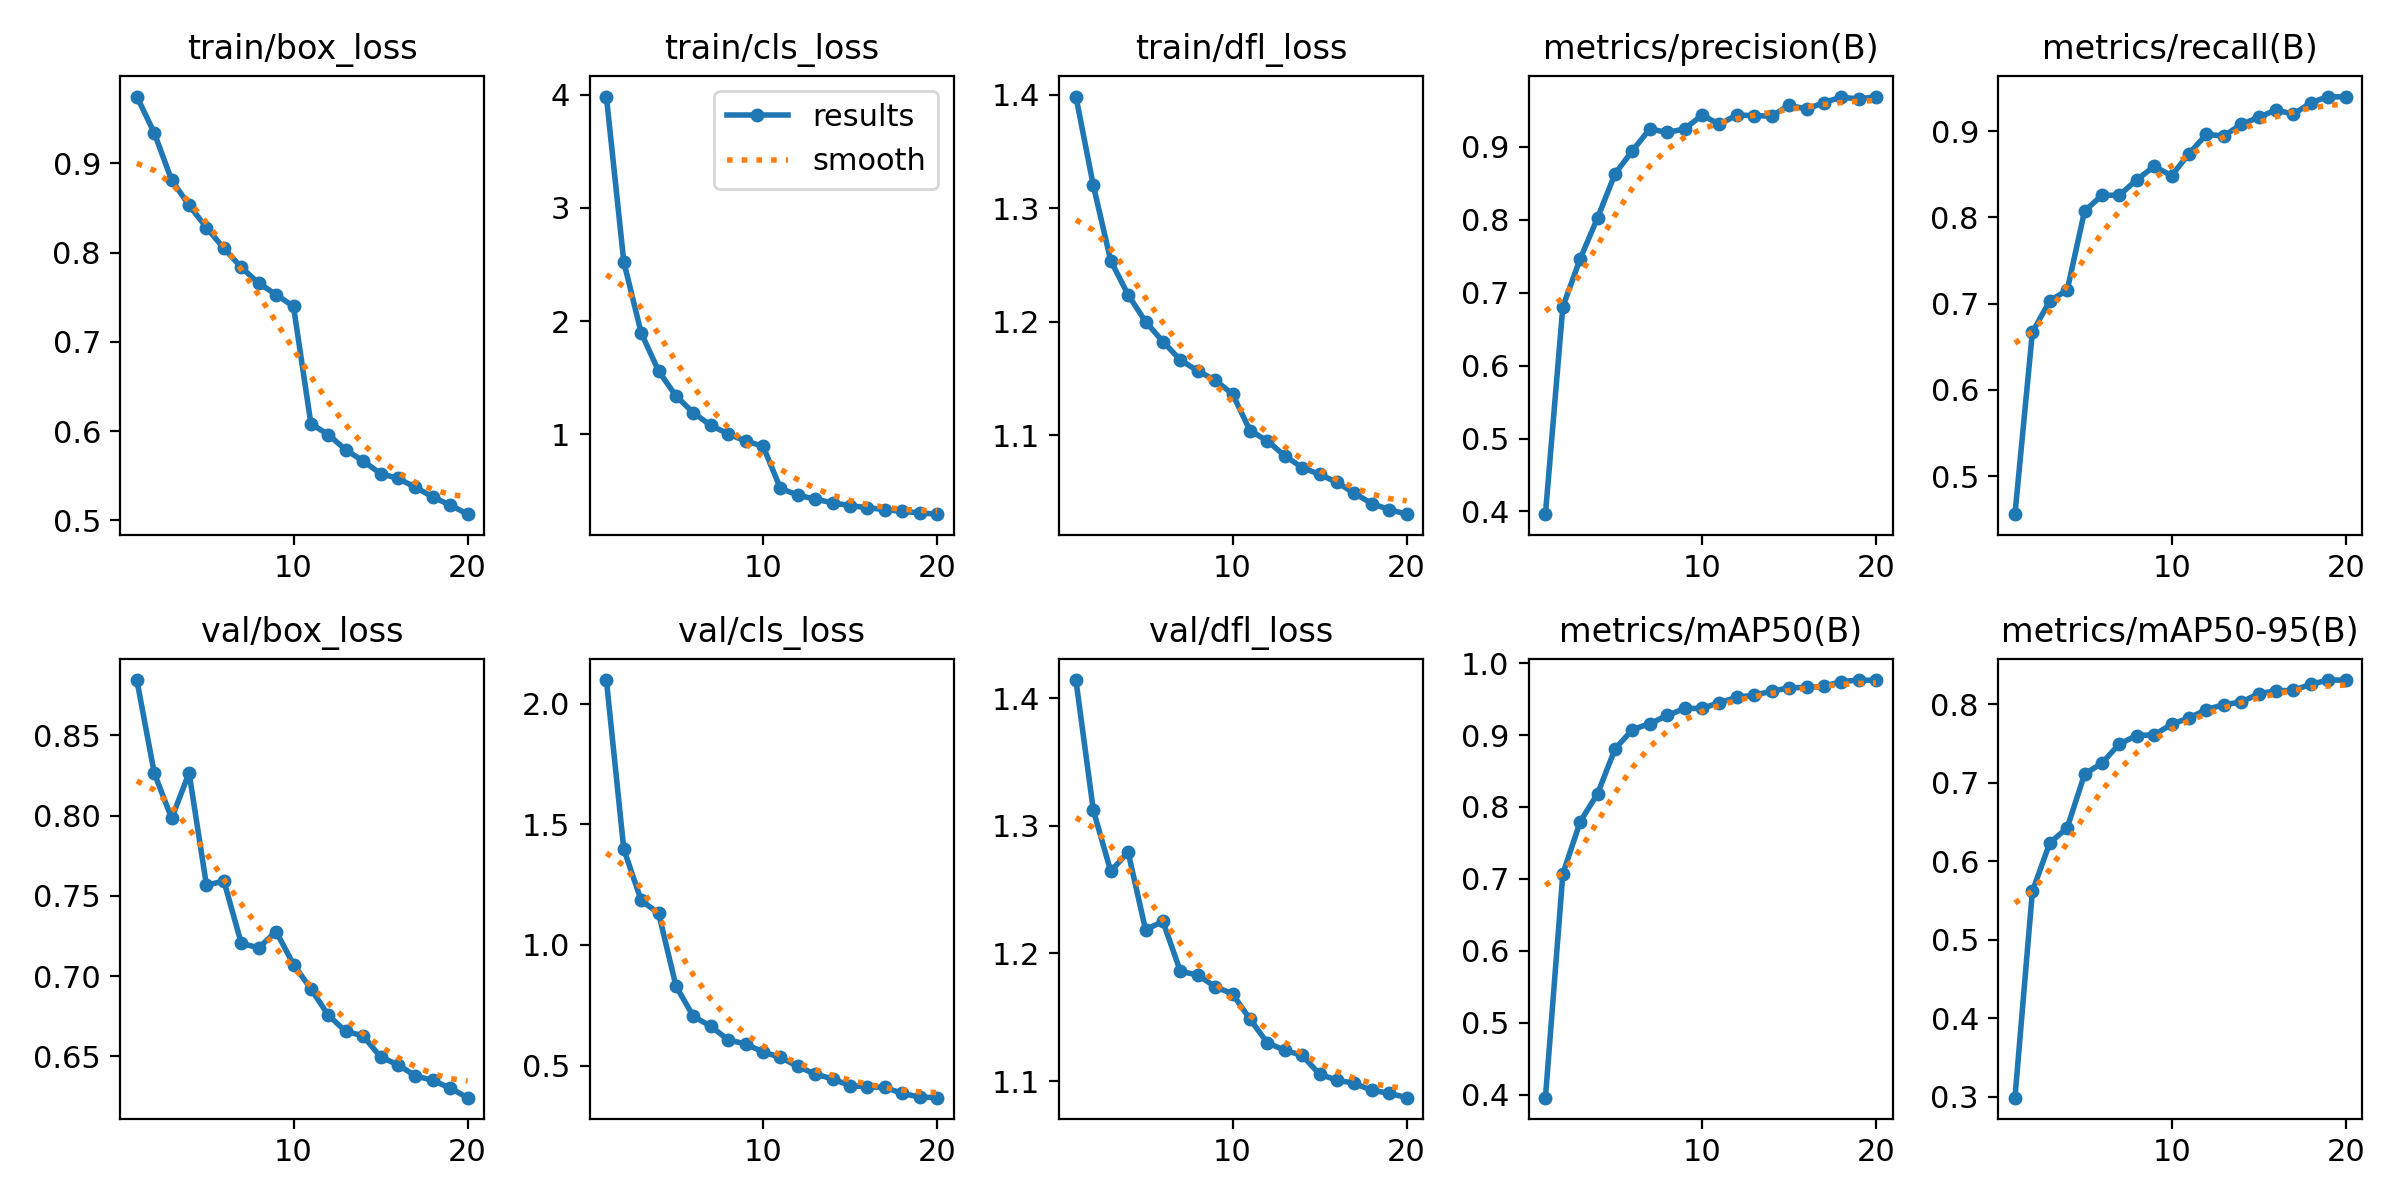


=== val_batch0_pred.jpg ===


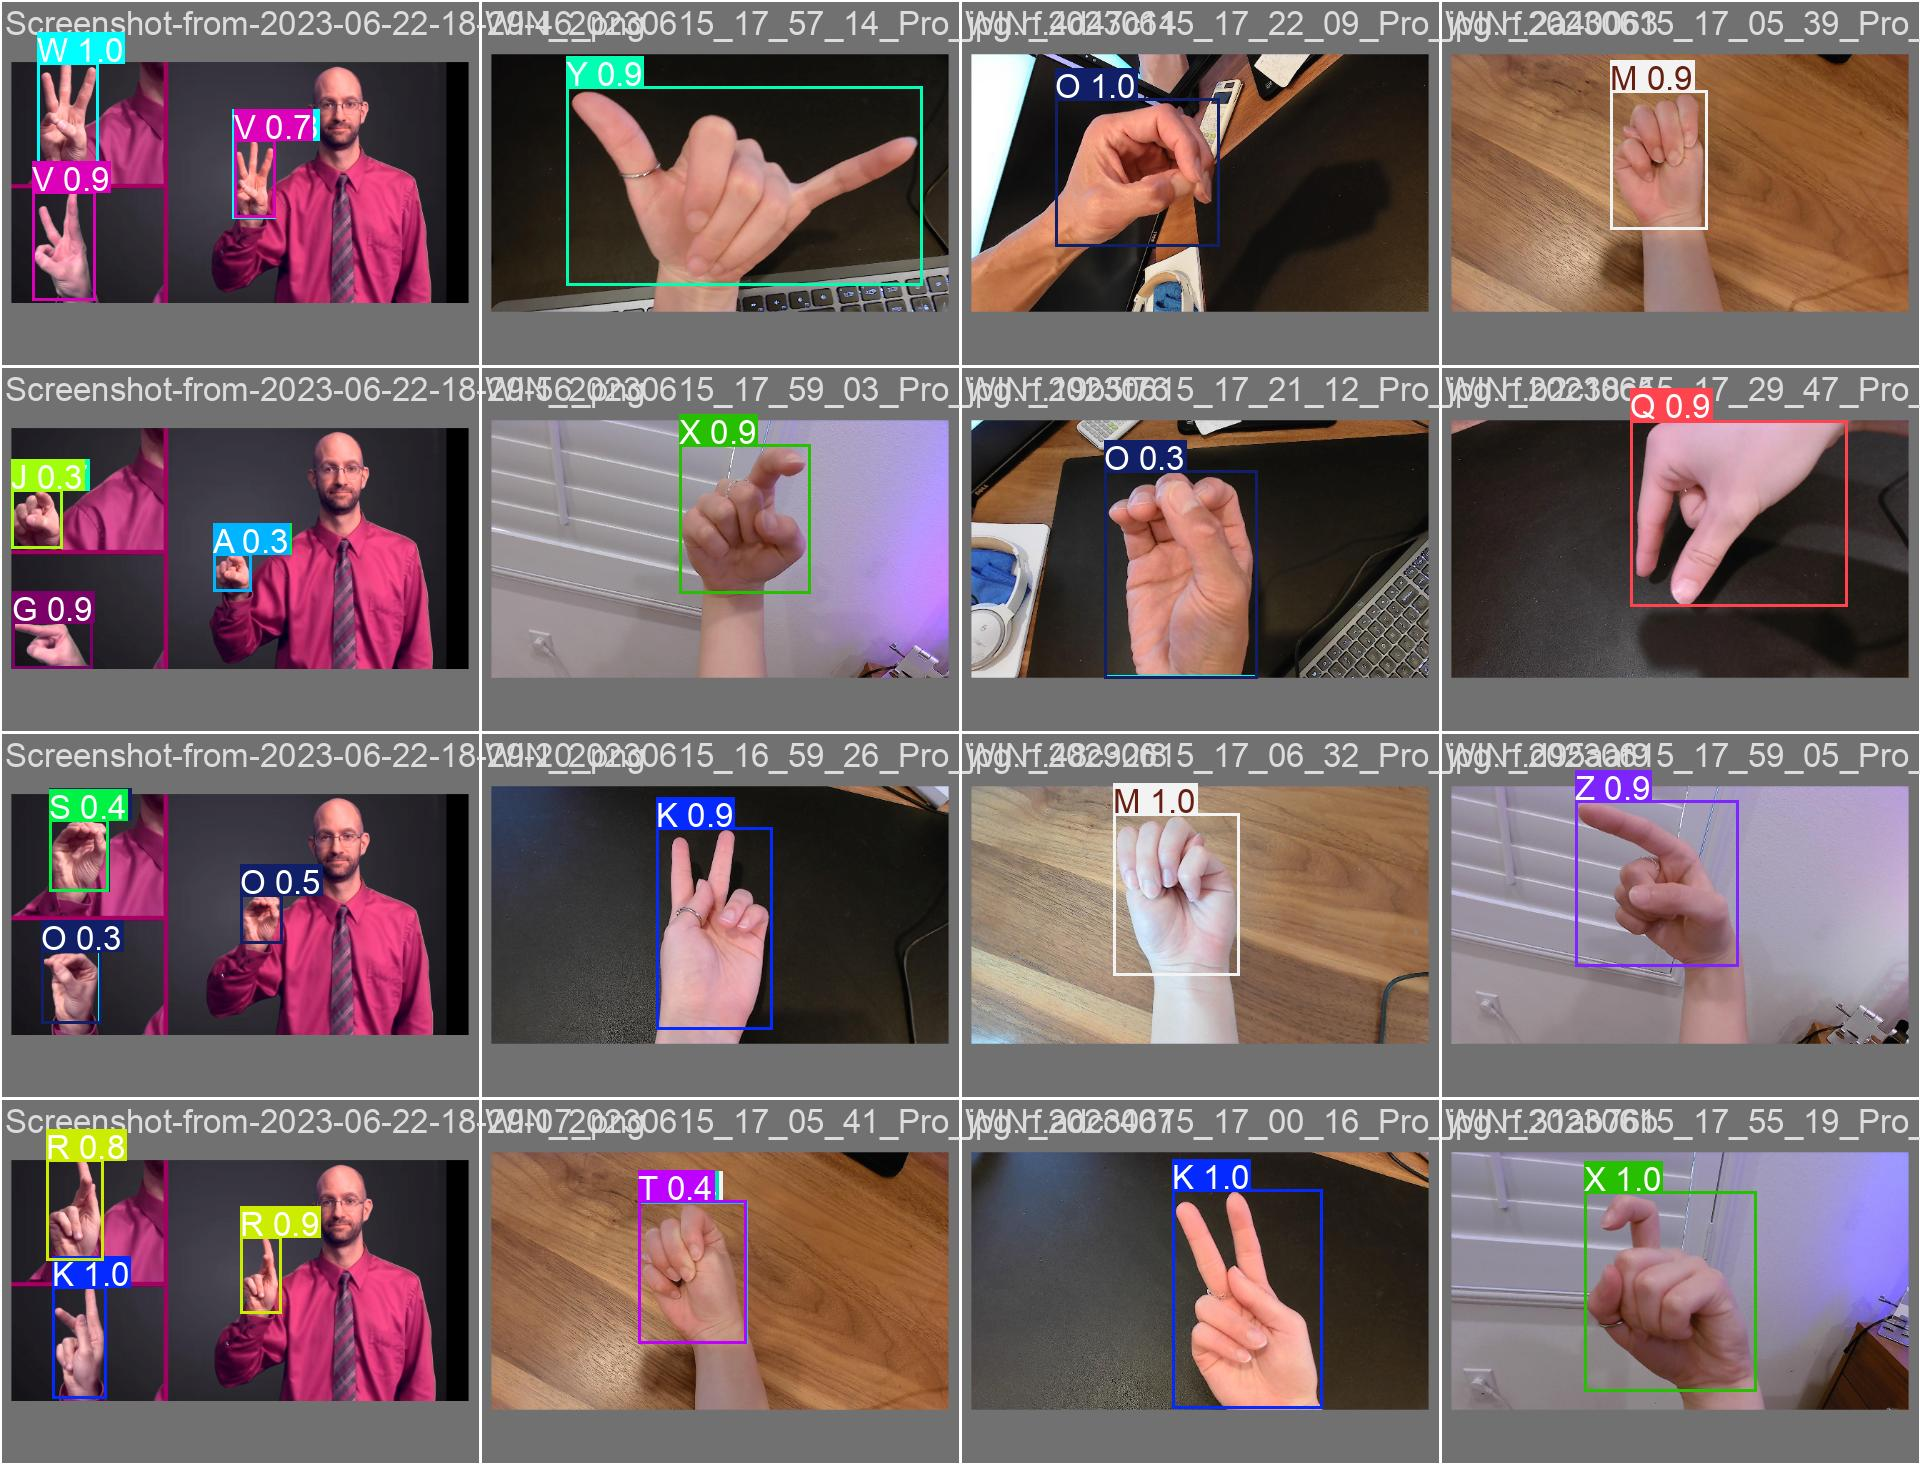

In [ ]:
# Display training curves and sample predictions
from IPython.display import Image, display

for figure_name in ['results.png', 'val_batch0_pred.jpg']:
    path = os.path.join(run_dir, figure_name)
    if os.path.exists(path):
        print(f'\n=== {figure_name} ===')
        display(Image(filename=path))
    else:
        print(f'(missing: {path})')

In [ ]:
# Run inference on one random validation image as a quick visual check
import glob
import random

valid_images = glob.glob(os.path.join(dataset.location, 'valid', 'images', '*.jpg'))
if valid_images:
    sample = random.choice(valid_images)
    print(f'Predicting on: {os.path.basename(sample)}')
    model.predict(source=sample, conf=0.5, save=True,
                  project='runs/detect', name='single_pred', exist_ok=True)
    saved_path = os.path.join('runs/detect/single_pred', os.path.basename(sample))
    if os.path.exists(saved_path):
        display(Image(filename=saved_path))
else:
    print('No validation images found.')

Predicting on: e90cda83-0b46-41ca-8de5-58dfedc7883d-rgb_0000_png.rf.f530414e1086b78cb10de596bcd0bcc9.jpg

image 1/1 /content/ASL-Alphanumeric-Signs-2-1/valid/images/e90cda83-0b46-41ca-8de5-58dfedc7883d-rgb_0000_png.rf.f530414e1086b78cb10de596bcd0bcc9.jpg: 640x640 1 T, 19.5ms
Speed: 5.7ms preprocess, 19.5ms inference, 6.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/runs/detect/single_pred


In [ ]:
# Pull confusion matrix from validation results
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_full = metrics.confusion_matrix.matrix
class_names_full = list(model.names.values())
print(f'Matrix shape: {cm_full.shape},  total samples: {int(cm_full.sum())}')

Matrix shape: (37, 37),  total samples: 1989


In [ ]:
# Filter rows and columns to only letters A-Z, alphabetically sorted
letter_set = {chr(c) for c in range(ord('A'), ord('Z') + 1)}
letter_indices = [i for i, n in enumerate(class_names_full)
                  if n.strip().upper() in letter_set]
letter_indices.sort(key=lambda i: class_names_full[i].upper())
letter_names = [class_names_full[i].upper() for i in letter_indices]

cm_letters = cm_full[np.ix_(letter_indices, letter_indices)]

# Convert raw counts to per-row percentages
row_sums = cm_letters.sum(axis=1, keepdims=True)
cm_letters_pct = np.divide(cm_letters, row_sums,
                           out=np.zeros_like(cm_letters, dtype=float),
                           where=row_sums > 0) * 100.0

# Build cell-label matrix that hides zeros
letter_labels = np.empty_like(cm_letters_pct, dtype=object)
for i in range(cm_letters_pct.shape[0]):
    for j in range(cm_letters_pct.shape[1]):
        letter_labels[i, j] = (f'{cm_letters_pct[i, j]:.0f}'
                               if cm_letters_pct[i, j] > 0 else '')

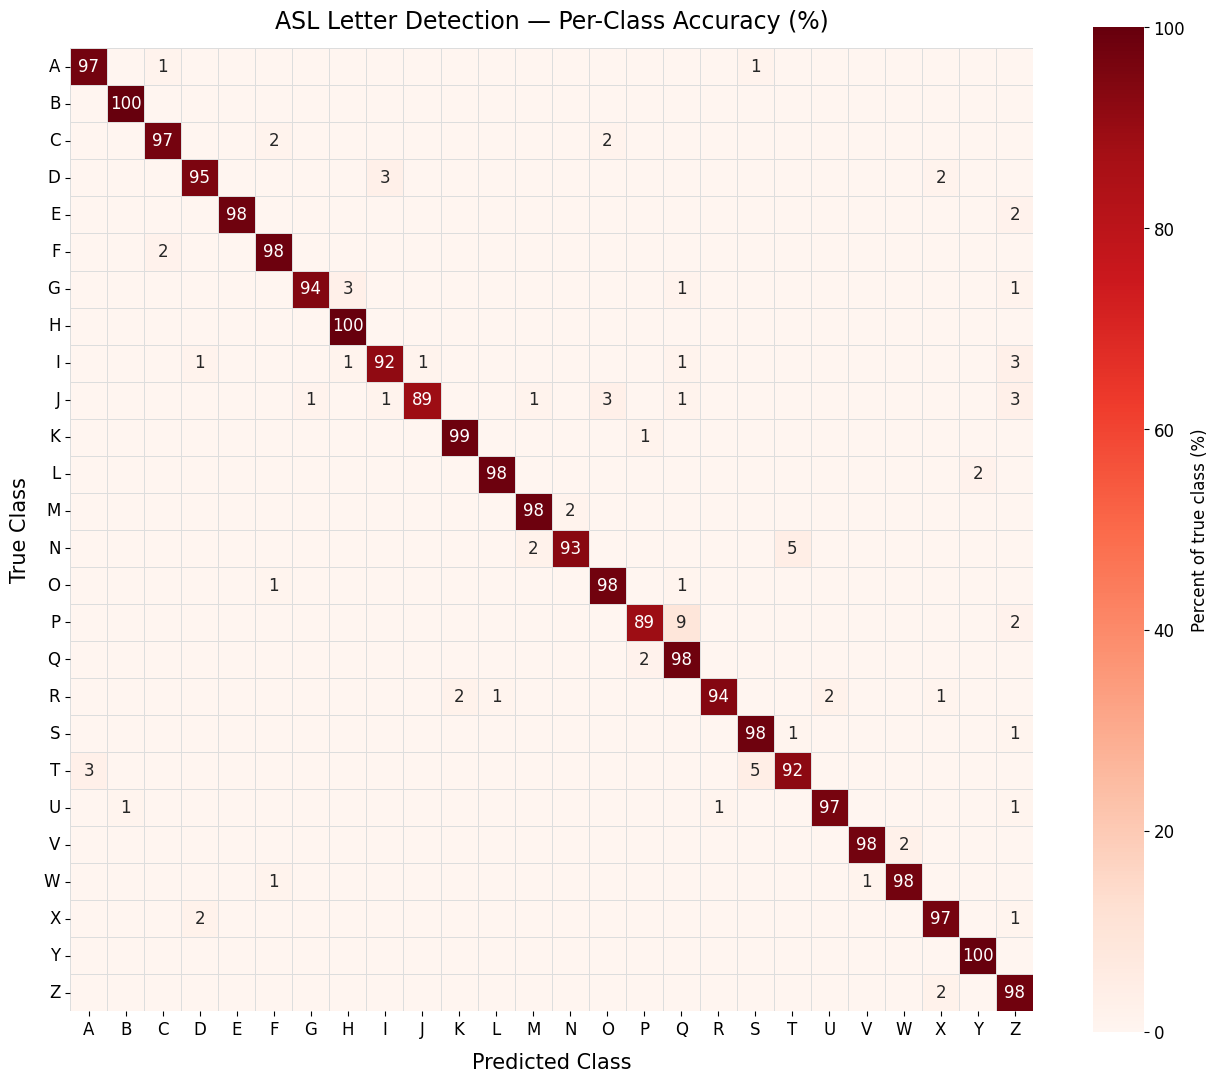

Saved: confusion_matrix_letters.png and .pdf


In [ ]:
# Plot letters-only confusion matrix and save high-res copies
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12})

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    cm_letters_pct, annot=letter_labels, fmt='', cmap='Reds',
    vmin=0, vmax=100,
    xticklabels=letter_names, yticklabels=letter_names,
    cbar_kws={'label': 'Percent of true class (%)'},
    linewidths=0.4, linecolor='#dddddd',
    square=True, ax=ax,
)
ax.set_xlabel('Predicted Class', fontsize=15, labelpad=10)
ax.set_ylabel('True Class', fontsize=15, labelpad=10)
ax.set_title('ASL Letter Detection — Per-Class Accuracy (%)',
             fontsize=17, pad=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig('confusion_matrix_letters.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.savefig('confusion_matrix_letters.pdf',
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: confusion_matrix_letters.png and .pdf')

In [ ]:
# Print summary stats and worst confusions for the discussion section
diagonal = np.diag(cm_letters_pct)
print(f'Letter-only mean per-class accuracy: {diagonal.mean():.1f}%')
print(f'Best letter:  {letter_names[diagonal.argmax()]} ({diagonal.max():.1f}%)')
print(f'Worst letter: {letter_names[diagonal.argmin()]} ({diagonal.min():.1f}%)')

# Finds most mistakenly predicted items
off_diag = cm_letters_pct.copy()
np.fill_diagonal(off_diag, 0)
print('\nTop confusions (true → predicted):')
for _ in range(5):
    i, j = np.unravel_index(off_diag.argmax(), off_diag.shape)
    if off_diag[i, j] == 0:
        break
    print(f'  {letter_names[i]} → {letter_names[j]}: {off_diag[i, j]:.0f}%')
    off_diag[i, j] = 0

Letter-only mean per-class accuracy: 96.4%
Best letter:  B (100.0%)
Worst letter: P (88.9%)

Top confusions (true → predicted):
  P → Q: 9%
  T → S: 5%
  N → T: 5%
  D → I: 3%
  T → A: 3%


Full 36-Class Confusion Matrix (Raw Counts)

In [ ]:
# Strip background row/col and order classes: digits 1-10 first, then A-Z
n_classes = len(class_names_full)
cm_classes = cm_full[:n_classes, :n_classes]

digit_set = {str(d) for d in range(1, 11)}
digit_indices = [i for i, n in enumerate(class_names_full)
                 if n.strip() in digit_set]
digit_indices.sort(key=lambda i: int(class_names_full[i]))

all_indices = digit_indices + letter_indices
all_names = [class_names_full[i] for i in all_indices]

cm_all = cm_classes[np.ix_(all_indices, all_indices)].astype(int)

In [ ]:
# Build cell labels showing raw counts, blank where zero
all_labels = np.empty_like(cm_all, dtype=object)
for i in range(cm_all.shape[0]):
    for j in range(cm_all.shape[1]):
        all_labels[i, j] = f'{cm_all[i, j]}' if cm_all[i, j] > 0 else ''

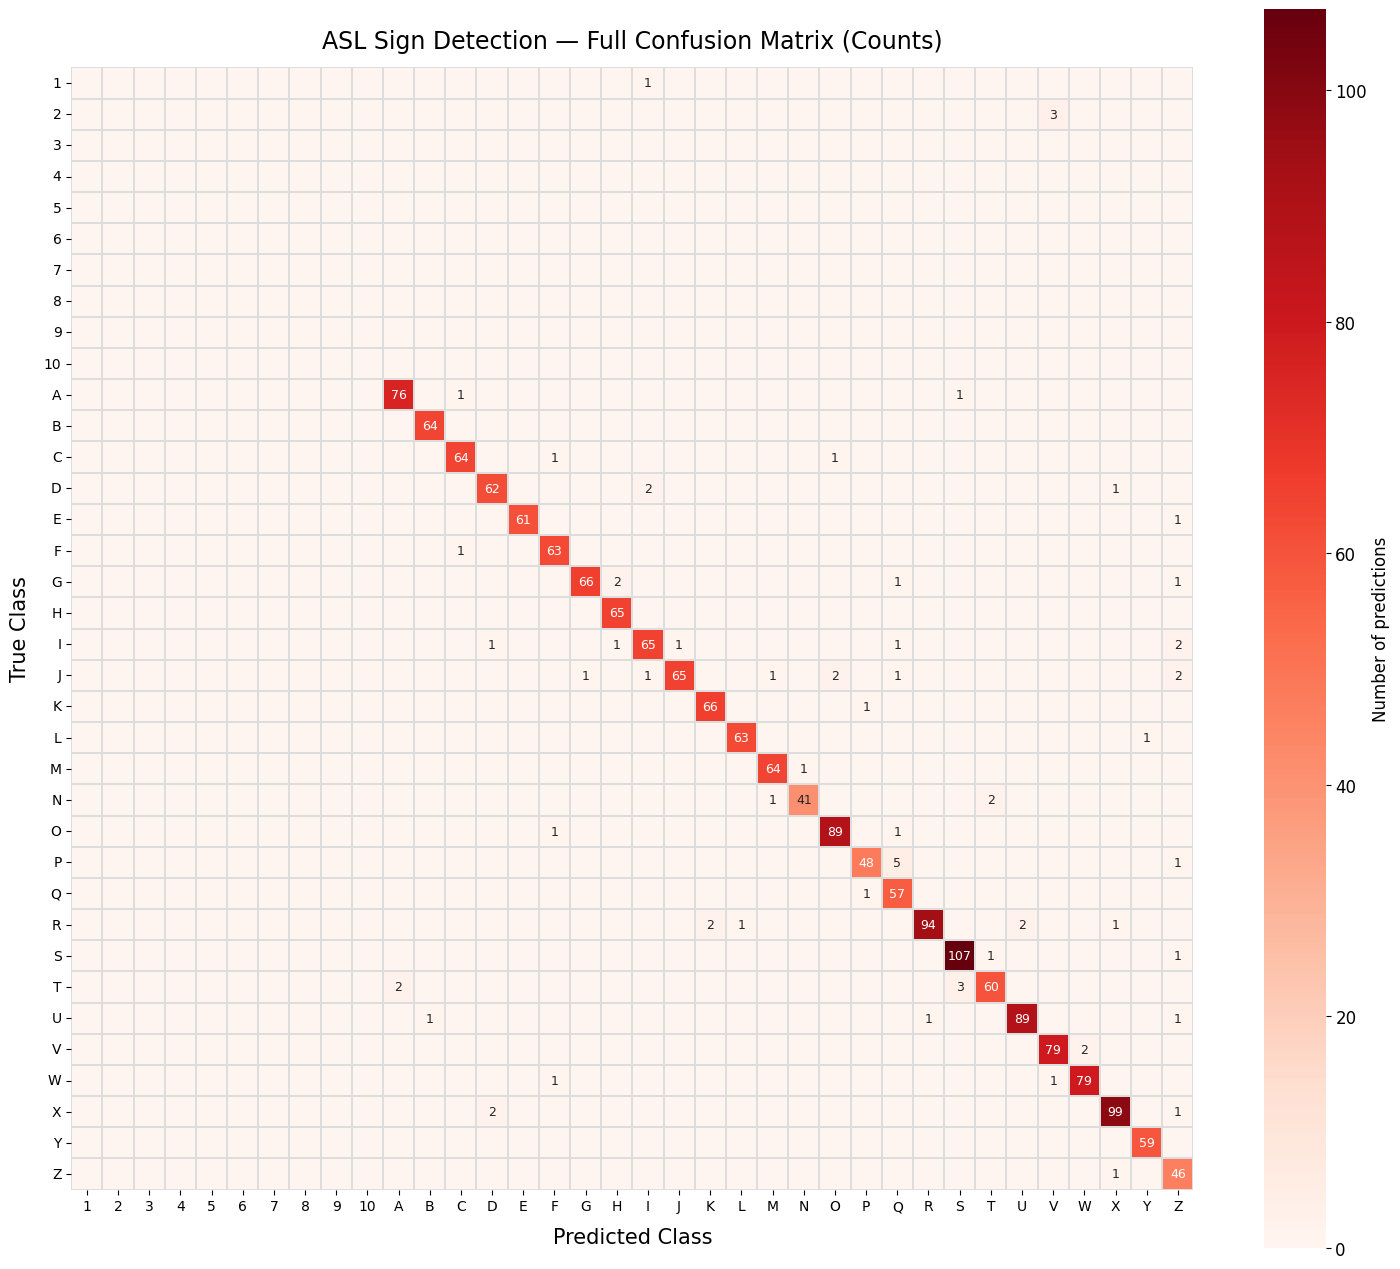

Saved: confusion_matrix_full.png and .pdf


In [ ]:
# Plot 36-class matrix with raw counts and save high-res copies
vmax = cm_all.max() if cm_all.max() > 0 else 1

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(
    cm_all, annot=all_labels, fmt='', cmap='Reds',
    vmin=0, vmax=vmax,
    xticklabels=all_names, yticklabels=all_names,
    cbar_kws={'label': 'Number of predictions'},
    linewidths=0.3, linecolor='#dddddd',
    square=True, ax=ax, annot_kws={'size': 9},
)
ax.set_xlabel('Predicted Class', fontsize=15, labelpad=10)
ax.set_ylabel('True Class', fontsize=15, labelpad=10)
ax.set_title('ASL Sign Detection — Full Confusion Matrix (Counts)',
             fontsize=17, pad=14)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

plt.savefig('confusion_matrix_full.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.savefig('confusion_matrix_full.pdf',
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: confusion_matrix_full.png and .pdf')

Pull the trained weights and figures off Colab. Drop `best.pt` into the same folder as `asl_yolo_webcam.py`.